In [98]:
import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()



import os

def create_subfolders(parent_directory, subfolder_names, nested_subfolder_names):
    for folder_name in subfolder_names:
        # Construct the full path for the new subfolder
        subfolder_path = os.path.join(parent_directory, folder_name)
        try:
            # Create the main subfolder
            os.makedirs(subfolder_path)
            print(f"Created subfolder: {subfolder_path}")

            # Create nested subfolders
            for nested_folder_name in nested_subfolder_names:
                nested_subfolder_path = os.path.join(subfolder_path, nested_folder_name)
                os.makedirs(nested_subfolder_path)
                print(f"Created nested subfolder: {nested_subfolder_path}")
        except OSError as error:
            print(f"Error creating subfolder {subfolder_path}: {error}")

# # Define the parent directory
# parent_directory = "solns_runs/Ex4"

# # Generate main subfolder names T1, T2, ..., T50
# subfolder_names = [f"T{i}" for i in range(1, 51)]

# # Generate nested subfolder names N100, N200, ..., N1500
# nested_subfolder_names = [f"N{i}" for i in range(100, 1501, 100)]

# # Create the subfolders
# create_subfolders(parent_directory, subfolder_names, nested_subfolder_names)


def F(x, lam):
    x_val, y_val = x
    return np.array([2*(x_val-1)+lam, 2*(y_val-0.5)+lam])


def proj_X_opt(x):
    """
    Project point x = (x1, x2) onto
    X = { (u,v) | u >= 0, v >= 0, u+v <= 1 }
    """
    x = np.asarray(x)

    # Objective: minimize squared distance
    def objective(u):
        return 0.5 * np.sum((u - x)**2)

    # Constraints
    constraints = [
        {"type": "ineq", "fun": lambda u: 1 - u[0] - u[1]} # u+v <= 15
    ]

    # Initial guess
    z0 = np.maximum(x, 0)  # clip negative values to start inside nonnegative orthant
    bounds = [(0, 1), (0, 1)]

    result = minimize(objective, z0, constraints=constraints, bounds= bounds)

    return result.x


def const(x):
    return 1-(x[0]+x[1])


# ------------------- Projected gradient VI solver -------------------
n_runs= 3
def vi_solver(l, step=0.001, max_iter=200, tol=1e-4):
    x0= np.random.uniform(0, 1, size=2)
    x = x0.copy()
    for _ in range(max_iter):
        x_new = proj_X_opt(x - step * F(x, l))
        if np.linalg.norm(x_new - x) < tol:
            if np.linalg.norm(const(x_new)*l)<= 1e-6:
                return x_new
        x = x_new
    if np.linalg.norm(const(x_new)*l)<= 1e-6:
        return x_new
    else:
        return None



def constraint_function(x):
#     return np.array([x[0] + x[1] - 1])
    return np.array([1-(x[0] + x[1])])

def gradient_x1(x):
    return 1.0

def gradient_x2(x):
    return 1.0

def gradient(x):
    return np.array([gradient_x1(x),gradient_x2(x)])
def F(x, lamd):
    return np.array([2*(x[0]-1)+lamd*gradient_x1(x),2*(x[1]-0.5)+lamd*gradient_x2(x)])

n= 2
alpha= np.random.uniform(0, sqrt(2)-1)
# alpha= sqrt(2)-1
alpha


def constraint_function(x):
#     return np.array([x[0] + x[1] - 1])
    return np.array([1-(x[0] + x[1])])

def gradient_x1(x):
    return 1.0

def gradient_x2(x):
    return 1.0

def gradient(x):
    return np.array([gradient_x1(x),gradient_x2(x)])
def F(x, lamd):
    return np.array([2*(x[0]-1)+lamd*gradient_x1(x),2*(x[1]-0.5)+lamd*gradient_x2(x)])

n= 2
alpha= np.random.uniform(0, sqrt(2)-1)


def project_into_feasible_set(x,constraint_function):
    result = minimize(lambda x_prime: np.linalg.norm(x_prime - x), x, constraints={'type': 'ineq', 'fun': constraint_function},bounds= [(0,1),(0,1)])
    return result.x

num_iterations= 100
def projected_gradient_descent_kkt(F,initial_x, initial_y, lambda_value,lamd):
    x = initial_x.copy()
    y = initial_y.copy()


    grad_obj = F(y,lamd)
    x = project_into_feasible_set(x -  lambda_value *grad_obj, constraint_function)
    return x


def vi_solver(lamd):
    n= 2
    x0= np.random.uniform(0, 1, size=n)
    y0= x0.copy()

    T= 1000
    x,y= np.zeros((T+1,n)),np.zeros((T+1,n))
    x[0]= x0
    y[0]= y0
    lambda_value_0= np.random.uniform(0, alpha)
#     print(x0)
    x[1]= projected_gradient_descent_kkt(F,x[0], y[0], lambda_value_0, lamd)
    y[1]= 2*x[1]-x[0]
    for i in range(1,T):

        if np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))!= 0.0:
            lambda_value= np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd)))
        else:
            lambda_value= 1e-8 # np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))+1e-8)
      # break
#         print(x[i])
        x[i+1]= projected_gradient_descent_kkt(F,x[i], y[i], lambda_value,lamd)
        y[i+1]= 2*x[i+1]-x[i]
#         print(x[i+1])
        
#         print(np.linalg.norm(x[i+1] - x[i]))
        
        if (np.linalg.norm(x[i+1] - x[i])) <= 1e-4:
            if np.abs(const(x[i+1]) * lamd) <= 1e-6:
                return x[i+1]
#             np.linalg.norm(x[i+1] - y[i]) <= 1e-4):
#             print(f"Converged at iteration {i}")
            
    
#             if lambda_value== 0.0:
#                 return x[i+1]
#             if np.linalg.norm(const(x[i+1])*lambda_value)<= 1e-6:
#                 return x[i+1]
#             elif np.abs(const(x[i+1])) < 1e-8:
#                 return x[i+1]
            

def organize_solutions(solns):
    set_of_points= []
    for sol in solns:
        if sol is not None:
            set_of_points.append(list(sol))

    return set_of_points

def discretize_time_interval(T,num_points):
    """
    Discretize the time interval [0, T] with a given time step (delta_t).

    Parameters:
    - T: Total time duration
    - delta_t: Time step size

    Returns:
    - time_points: List of discretized time points
    """
    start = 0.0#T-1

    # Calculate the width of each sub-interval
    interval_width = (T - start) / (num_points - 1)

    # Generate the points
    points = [start + i * interval_width for i in range(num_points)]

    return points

number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
#number_points_list= [10, 20]
#n_runs= [5, 10, 15, 20, 25, 30, 35, 40, 50, 55, 60]
#number_points_list= [100, 200]
T_list= [T for T in range(1,2)]
# n_runs= [10]

def run_for_lam(lmb):
    results = Parallel(n_jobs=-1)(delayed(vi_solver)(lam) for lam in lmb)
    set_of_points= organize_solutions(results)
    return set_of_points


def run_n(lmb, n_r= 10):
    results = Parallel(n_jobs=8)(delayed(run_for_lam)(lmb) for _ in range(n_r))
    set_of_points= organize_solutions(results)
    res= []
    for i in set_of_points:
        res.extend(i)
    return np.array(res)
    

def run_(lambd):
    results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lam) for lam in lambd)
    set_of_points= organize_solutions(results)
    return set_of_points
def run_for_lam_run(lmb,n_runs):
    results = Parallel(n_jobs=8)(delayed(run_)(lmb) for _ in range(n_runs))
#     results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lmb) for _ in range(n_runs))
    set_of_points= organize_solutions(results)
    return set_of_points


# def run_for_different_runs(T,n_r= 10):
#     lambd = Parallel(n_jobs=2)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)
#     result= run_for_lam_run(lambd,n_r)
   
#     for idx_run in range(n_r):
#         results= result[idx_run]
# # #         results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lam) for lam in lambd)
#         for n_points in range(len(results)):
#             np.savetxt('./solns_runs/Ex4/T'+str(T)+'/'+'N'+str(number_points_list[n_points])+"/"+str(idx_run+1)+"_"+"solns"+'_'+'run'+str(n_r)+'_'+str(number_points_list[n_points])+'pts'+'.txt', np.array(results[n_points]), delimiter=',')




In [99]:
T= 1
lambd = Parallel(n_jobs=2)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)


In [100]:
len(lambd)
vi_solver(0.0)
#lambd[0]

array([0.76254071, 0.23745929])

In [101]:
tt= run_for_lam(lambd[0])

In [102]:
# tt= run_n(lambd[0],3)

In [103]:
tt

[[0.8029106057690077, 0.19708939423100733],
 [0.790407127633493, 0.209592872366507],
 [0.795928765235111, 0.20407123476488886],
 [0.6528003399089833, 0.3471996600910167],
 [0.7828816886913406, 0.21711831130865944],
 [0.7537972342006182, 0.24620276579938186],
 [0.804481868426032, 0.19551813157396783],
 [0.7785522098738765, 0.22144779012612342],
 [0.7900581277061721, 0.20994187229382796],
 [0.7792843848750036, 0.22071561512499635],
 [0.7882430639886631, 0.21175693601133694],
 [0.7863407232630965, 0.21365927673690355],
 [0.7855247103798649, 0.2144752896201351],
 [0.7836138883026077, 0.21638611169739225],
 [0.7880219402582749, 0.21197805974172343],
 [0.7498338842153521, 0.2501661157846479],
 [0.7797536349317729, 0.2202463650682271],
 [0.7810847791269738, 0.21891522087302612],
 [0.7774449569114344, 0.22255504308856552],
 [0.773503814423497, 0.22649618557650286],
 [0.7987331678209514, 0.20126683217904864],
 [0.7733578262057965, 0.22664217379420357],
 [0.7751293378040023, 0.22487066219599777]

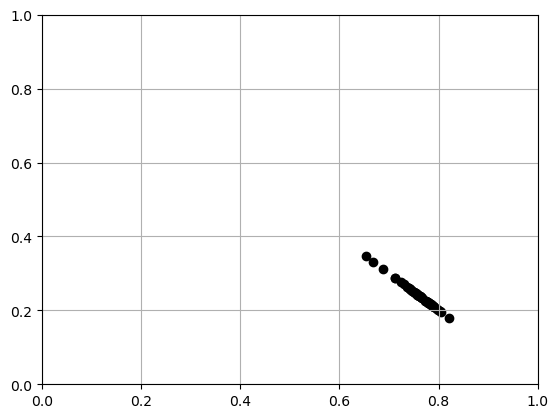

In [104]:
plt.scatter(np.array(tt)[:,0], np.array(tt)[:,1], c= 'black')
plt.xlim([0,1])
plt.ylim([0,1])
plt.grid(True)
plt.show()

In [105]:
# vi_solver(0.0)

In [106]:
# data= []
# for l in range(len(lambd)):
#     print(l)
#     res= run_for_lam(lambd[l])
#     data.append(res)

In [107]:
# data

In [108]:
# all_data= dict.fromkeys(range(len(data)), 0)

In [109]:
# for i in range(len(data)):
#     all_data[i]= data[i]

In [110]:
# import json
# with open("Ex1PVI.json", "w") as f:
#     json.dump(all_data, f)

In [111]:
# Filter solutions

In [112]:
# T= 5
# n_runs= 3

In [113]:
# All T

In [114]:
def runT(T):
    lambd = Parallel(n_jobs=6)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)
    data= []
    for l in range(len(lambd)):
        res= run_n(lambd[l])
        data.append(res)
    return data

In [115]:
T_list= [1, 2, 3, 4, 5]

T_data= dict.fromkeys(range(1, len(T_list)+1), 0)

T_data

{1: 0, 2: 0, 3: 0, 4: 0, 5: 0}

In [116]:
for T in T_list:
    print("Running for T= ", T)
    res= runT(T)
    T_data[T]= res
    print(len(res))

Running for T=  1
15
Running for T=  2
15
Running for T=  3
15
Running for T=  4
15
Running for T=  5
15


In [117]:
T

5

In [119]:
import json
import numpy as np

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

with open("Ex1PVIT.json", "w") as f:
    json.dump(T_data, f, default=convert)

In [120]:
T_data[5]

[array([[0.793842  , 0.206158  ],
        [0.79570745, 0.20429255],
        [0.77693361, 0.22306639],
        [0.75954128, 0.24045872],
        [0.74701194, 0.25298806],
        [0.75804201, 0.24195799],
        [0.76107619, 0.23892381],
        [0.72958095, 0.27041905],
        [0.76979835, 0.23020165],
        [0.75208728, 0.24791272],
        [0.7847438 , 0.2152562 ],
        [0.79389618, 0.20610382],
        [0.78389659, 0.21610341],
        [0.77685933, 0.22314067],
        [0.74063665, 0.25936335],
        [0.75393224, 0.24606776],
        [0.76649423, 0.23350577],
        [0.75670735, 0.24329265],
        [0.74770777, 0.25229223],
        [0.75049495, 0.24950505],
        [0.80520302, 0.19479698],
        [0.78282866, 0.21717134],
        [0.78455421, 0.21544579],
        [0.7817106 , 0.2182894 ],
        [0.77306535, 0.22693465],
        [0.75845409, 0.24154591],
        [0.75699232, 0.24300768],
        [0.75430577, 0.24569423],
        [0.66960867, 0.33039133],
        [0.730

In [121]:
res

[array([[0.793842  , 0.206158  ],
        [0.79570745, 0.20429255],
        [0.77693361, 0.22306639],
        [0.75954128, 0.24045872],
        [0.74701194, 0.25298806],
        [0.75804201, 0.24195799],
        [0.76107619, 0.23892381],
        [0.72958095, 0.27041905],
        [0.76979835, 0.23020165],
        [0.75208728, 0.24791272],
        [0.7847438 , 0.2152562 ],
        [0.79389618, 0.20610382],
        [0.78389659, 0.21610341],
        [0.77685933, 0.22314067],
        [0.74063665, 0.25936335],
        [0.75393224, 0.24606776],
        [0.76649423, 0.23350577],
        [0.75670735, 0.24329265],
        [0.74770777, 0.25229223],
        [0.75049495, 0.24950505],
        [0.80520302, 0.19479698],
        [0.78282866, 0.21717134],
        [0.78455421, 0.21544579],
        [0.7817106 , 0.2182894 ],
        [0.77306535, 0.22693465],
        [0.75845409, 0.24154591],
        [0.75699232, 0.24300768],
        [0.75430577, 0.24569423],
        [0.66960867, 0.33039133],
        [0.730

## END

# Track $T_{max}$

In [11]:
import json
import numpy as np

import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()

number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]

def constraint_function(x):
#     return np.array([x[0] + x[1] - 1])
    return np.array([1-(x[0] + x[1])])

import json

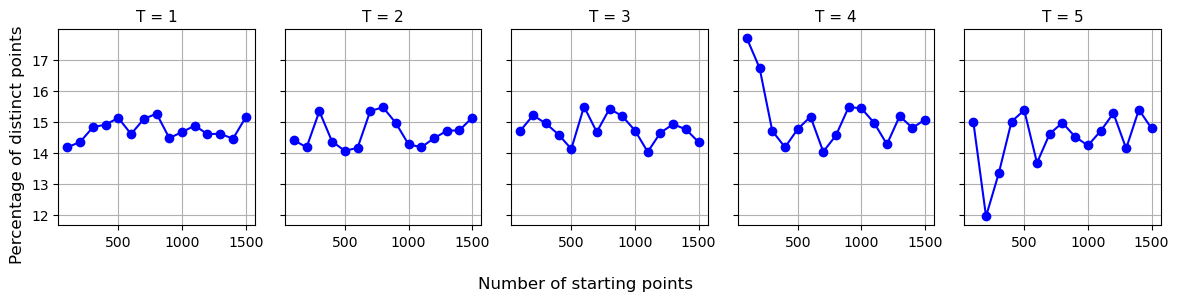

In [14]:
with open('./Ex1PVIT.json') as f:
    dataT= json.load(f)
    
    
T_list= [1, 2, 3, 4, 5] # T= 1 is the one giving meaningfull solution[1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)




for T in T_list:
    data_all= []

    for i in range(len(number_points_list)):
        res_= []
        # print(dataT[str(T)][i])

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            # print(data[str(i)])
            for t in range(len(dataT[str(T)][i])):
                # print(data[str(i)][t])
                #if np.abs(constraint_function(dataT[str(T)][i][t]))< 1e-6:
                res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all
    
    
res_all= []

for i in range(len(number_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)
    
data_all= res_all


dt_res= []

for i in range(len(number_points_list)):
    cleaned_data = [x for x in data_all[i] if x != []]
    # print(cleaned_data)
    dt_res.append(cleaned_data)
    # break

data_all= dt_res


import numpy as np
from scipy.spatial import KDTree

def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

# def calculate_tolerance(points):
#     num_points = len(points)
#     tolerance = 1/num_points
#     return tolerance
    
# def count_repeated_points(points):
#     #points = points[np.lexsort((points[:, 1], points[:, 0]))]
#     n= len(points)
#     ep=  calculate_tolerance(points)
#     distinct_points = []

#     for point in points:
#         is_distinct = True
#         for distinct_point in distinct_points:
#             if calculate_distance(point, distinct_point) < ep:
#                 is_distinct = False
#                 break
#         if is_distinct:
#             distinct_points.append(point)
            
#     return len(distinct_points), distinct_points

def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    #n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points


res_T= {
    1: None, 2: None, 3: None, 4: None, 5:None
}
Tmax= 5

dist_= None
for t in range(1, Tmax+1):
    dist_= []

    for (idx, pt) in enumerate(number_points_list):




        num, distinct_points = count_repeated_points(np.array(data_dict[t][idx]))
        distinct_points= np.array(distinct_points)
        dist_.append((len(distinct_points)/(len(np.array(data_dict[t][idx]))))*100)
    res_T[t]= dist_

    
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(100, 1501, 100)

fig, axes = plt.subplots(1, Tmax, figsize=(12,3), sharex=True, sharey=True)

for T in range(1, Tmax+1):
    ax = axes[T-1]
    ax.plot(x, res_T[T], marker='o', c= 'blue')
    ax.set_title(f"T = {T}", fontsize=11)
    ax.grid(True)

# global labels
fig.supxlabel("Number of starting points", fontsize=12)
fig.supylabel("Percentage of distinct points", fontsize=12)

plt.tight_layout()
# plt.savefig("Ex1Tmax.png", dpi=300, bbox_inches="tight")
plt.show()

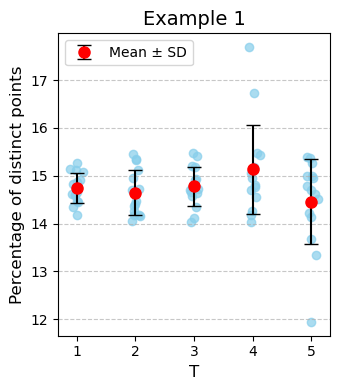

In [16]:
# Compute mean and std for each key
keys = list(res_T.keys())
means = [np.mean(res_T[k]) for k in keys]
stds = [np.std(res_T[k]) for k in keys]

plt.figure(figsize=(3.5,4))

# Plot all points with some horizontal jitter
for i, k in enumerate(keys):
    y = res_T[k]
    x = np.random.normal(loc=i+1, scale=0.05, size=len(y))  # jitter for visibility
    plt.scatter(x, y, color='skyblue', alpha=0.7, label='_nolegend_')

# Overlay mean as a red marker with error bars
plt.errorbar(keys, means, yerr=stds, fmt='o', color='red', ecolor='black', elinewidth=1.5,
             capsize=5, markersize=8, label='Mean ± SD')

# Formatting
plt.xticks(keys)
plt.xlabel('T', fontsize=12)
plt.ylabel('Percentage of distinct points', fontsize=12) # mean PDP across the number of starting points.
plt.title('Example 1', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("Ex1Tmax.png", dpi=300, bbox_inches="tight")
plt.show()